In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r"C:\Users\resha\Downloads\archive (7)\Titanic-Dataset.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape

(891, 12)

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

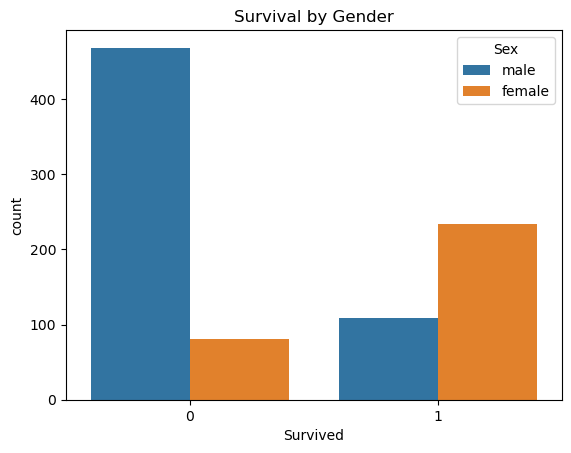

In [9]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")
plt.show()



In [10]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [11]:
from sklearn.impute import SimpleImputer

# For numerical columns
num_imputer = SimpleImputer(strategy="median")

# For categorical columns
cat_imputer = SimpleImputer(strategy="most_frequent")
num_cols = ['Age']
cat_cols = ['Embarked']
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [13]:
df.drop('Cabin', axis=1, inplace=True)

In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [17]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [18]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize'],
      dtype='object')

In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [20]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [21]:

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(df[['Sex','Embarked']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Sex', 'Embarked']))
df=pd.concat([df,encoded_df],axis=1)
df.drop(['Sex', 'Embarked'], axis=1, inplace=True)


In [22]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler = StandardScaler()
X_numerical = df[['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']]
X_scaled = scaler.fit_transform(X_numerical)
X_scaled = pd.DataFrame(X_scaled, columns=X_numerical.columns)
df[X_numerical.columns]= X_scaled

In [23]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [24]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,-0.565736,0.432793,-0.473674,-0.502445,0.059160,0.0,1.0,0.0,0.0,1.0
1,1,1,0.663861,0.432793,-0.473674,0.786845,0.059160,1.0,0.0,1.0,0.0,0.0
2,1,3,-0.258337,-0.474545,-0.473674,-0.488854,-0.560975,1.0,0.0,0.0,0.0,1.0
3,1,1,0.433312,0.432793,-0.473674,0.420730,0.059160,1.0,0.0,0.0,0.0,1.0
4,0,3,0.433312,-0.474545,-0.473674,-0.486337,-0.560975,0.0,1.0,0.0,0.0,1.0


In [25]:
from sklearn.base import BaseEstimator, TransformerMixin

class AddFamilySize(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
        return X

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Pclass']
categorical_cols = ['Sex', 'Embarked']

preprocessor = Pipeline([
    ('feature_engineering', AddFamilySize()), 
    
    ('column_transform', ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), numerical_cols),

        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]))
])

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

df_raw = pd.read_csv(r"C:\Users\resha\Downloads\archive (7)\Titanic-Dataset.csv")


X = df_raw[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Embarked']]
y = df_raw['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

full_pipeline.fit(X_train, y_train)

print("Accuracy:", full_pipeline.score(X_test, y_test))

Accuracy: 0.8212290502793296


In [28]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd


X_train_processed = preprocessor.fit_transform(X_train)

selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_processed)

print("Before:", X_train_processed.shape)
print("After:", X_train_selected.shape)

Before: (712, 11)
After: (712, 11)


[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000963 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 212
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

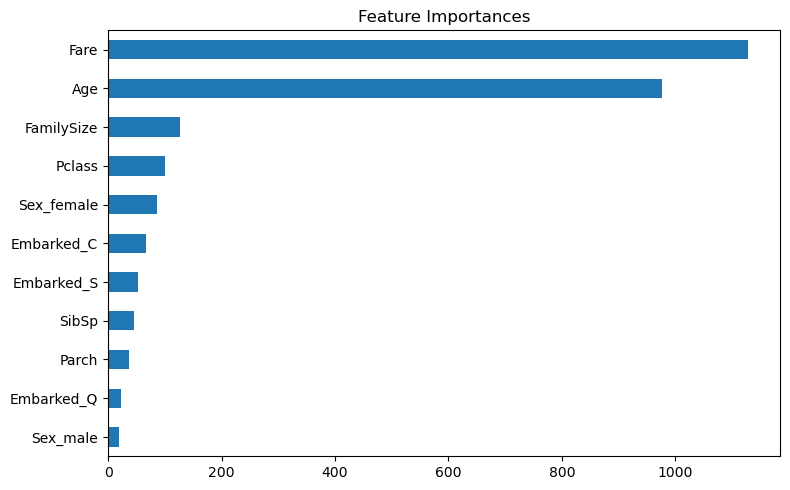

Top features: ['Fare', 'Age', 'FamilySize', 'Pclass', 'Sex_female', 'Embarked_C', 'Embarked_S', 'SibSp']


In [30]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd


X_train_processed = preprocessor.fit_transform(X_train)


lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train_processed, y_train)

column_transformer = preprocessor.named_steps['column_transform']

cat_pipeline = column_transformer.named_transformers_['cat']
encoder = cat_pipeline.named_steps['encode']

cat_features = encoder.get_feature_names_out(categorical_cols).tolist()


all_features = numerical_cols + cat_features

importances = pd.Series(lgb_model.feature_importances_, index=all_features)

importances.sort_values().plot(kind='barh', figsize=(8,5), title="Feature Importances")
plt.tight_layout()
plt.show()

top_features = importances.nlargest(8).index.tolist()
print("Top features:", top_features)

In [31]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rfe = RFE(estimator=RandomForestClassifier(random_state=42), 
          n_features_to_select=8)
rfe.fit(X_train_processed, y_train)

rfe_selected = [f for f, s in zip(all_features, rfe.support_) if s]
print("RFE Selected:", rfe_selected)

RFE Selected: ['Age', 'Fare', 'SibSp', 'FamilySize', 'Pclass', 'Sex_female', 'Sex_male', 'Embarked_S']


In [32]:
# Features agreed upon by both methods = most reliable
agreed = set(top_features) & set(rfe_selected)
print("agreed by both:", agreed)

agreed by both: {'Sex_female', 'FamilySize', 'Pclass', 'Age', 'SibSp', 'Embarked_S', 'Fare'}


In [33]:
# Lock in your final features
final_features = ['Fare', 'Age', 'FamilySize', 'Pclass', 
                  'Sex_female', 'SibSp', 'Embarked_S']

import numpy as np
feature_indices = [all_features.index(f) for f in final_features]

X_train_final = X_train_processed[:, feature_indices]
X_test_final  = preprocessor.transform(X_test)[:, feature_indices]

print("final training shape:", X_train_final.shape)

final training shape: (712, 7)


In [35]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)  # cleaner output

In [36]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
    }
    model = RandomForestClassifier(**params, random_state=42)
    score = cross_val_score(model, X_train_final, y_train, 
                           cv=5, scoring="accuracy").mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Accuracy:", round(study.best_value * 100, 2), "%")
print("Best Params:", study.best_params)

Best Accuracy: 83.42 %
Best Params: {'n_estimators': 85, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 5}


In [40]:
import xgboost as xgb
import lightgbm as lgb

# XGBoost
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
    }
    model = xgb.XGBClassifier(**params, random_state=42, verbosity=0)
    score = cross_val_score(model, X_train_final, y_train,
                           cv=5, scoring="accuracy").mean()
    return score

# LightGBM
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
    }
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
    score = cross_val_score(model, X_train_final, y_train,
                           cv=5, scoring="accuracy").mean()
    return score

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=50)

study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=50)

# Leaderboard
import pandas as pd
leaderboard = pd.DataFrame([
    {"Model": "Random Forest", "Accuracy": round(study.best_value*100, 2), "Best Params": study.best_params},
    {"Model": "XGBoost",       "Accuracy": round(study_xgb.best_value*100, 2), "Best Params": study_xgb.best_params},
    {"Model": "LightGBM",      "Accuracy": round(study_lgbm.best_value*100, 2), "Best Params": study_lgbm.best_params},
])

print(leaderboard[["Model", "Accuracy"]].sort_values("Accuracy", ascending=False))

C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-p

           Model  Accuracy
1        XGBoost     84.13
2       LightGBM     83.99
0  Random Forest     83.42


C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [41]:
from sklearn.ensemble import VotingClassifier

# Build best models with tuned params
best_rf = RandomForestClassifier(**study.best_params, random_state=42)
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0)
best_lgbm = lgb.LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1)

# Combine them
ensemble = VotingClassifier(estimators=[
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('lgbm', best_lgbm)
], voting='soft')  # soft = uses probabilities, more accurate than hard voting

# Evaluate
score = cross_val_score(ensemble, X_train_final, y_train, cv=5, scoring='accuracy').mean()
print("Ensemble Accuracy:", round(score * 100, 2), "%")

C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ensemble Accuracy: 82.86 %


C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb),
        ('lgbm', best_lgbm)
    ],
    final_estimator=LogisticRegression(),  # meta-learner decides who to trust
    cv=5
)

score = cross_val_score(stacking, X_train_final, y_train, cv=5, scoring='accuracy').mean()
print("Stacking Accuracy:", round(score * 100, 2), "%")

C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\resha\anaconda3\Lib\site-p

Stacking Accuracy: 83.0 %


C:\Users\resha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


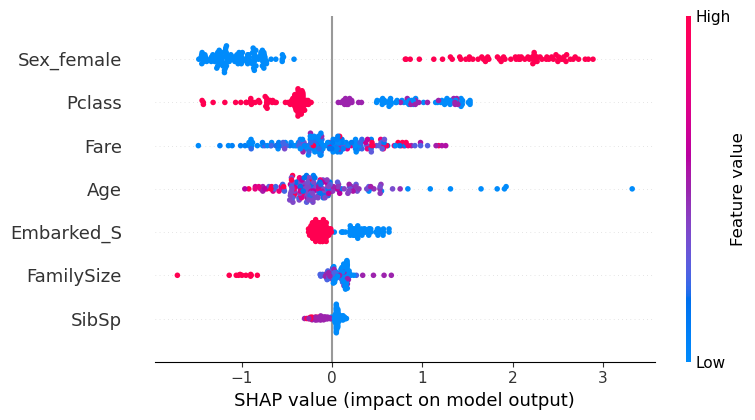

In [44]:
import shap

# Train final model
final_model = best_xgb
final_model.fit(X_train_final, y_train)

# Create explainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_final)

# Plot 1 — Feature Importance (global)
shap.summary_plot(shap_values, X_test_final, feature_names=final_features)

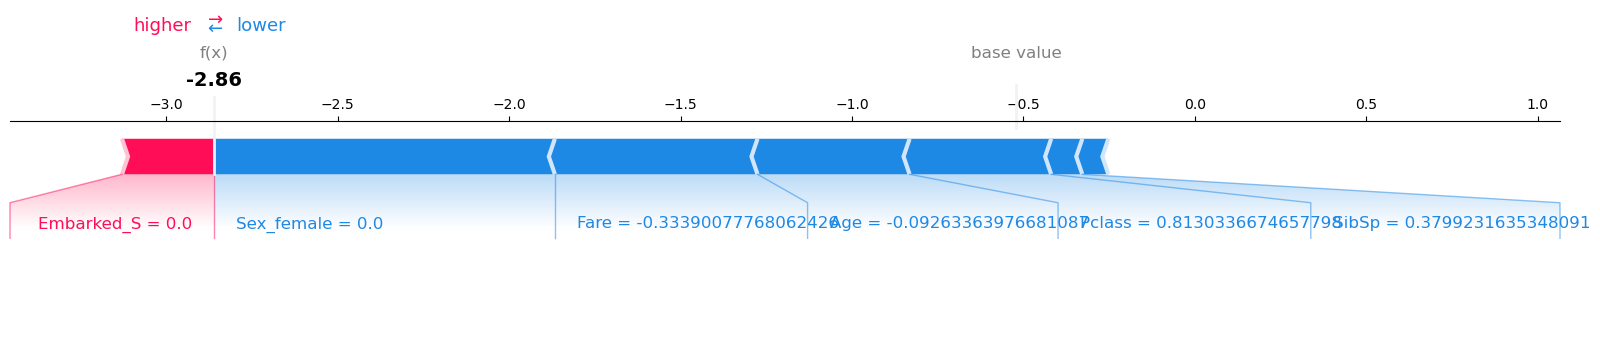

In [45]:
# Why did passenger 0 survive/not survive?
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_final[0],
    feature_names=final_features,
    matplotlib=True
)

In [46]:
import pickle

# Save model and preprocessor
with open('model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("Saved")

Saved
